# Retail Intelligence – Exploratory Data Analysis and Business Report

**Day 4 – Retail Intelligence SQL and Python Project**

This notebook analyzes results from two stages of the Retail Intelligence project:

- **Day 2 KPI Results** – Aggregated business metrics including revenue by city and store, category performance, customer spend tiers, promotion impact, top customers, product monthly revenue trends, store rankings, data quality issues, repeat purchase behaviour, and city-category revenue mix.
- **Day 3 Advanced Analytics Results** – RFM customer segmentation (Champions, Loyal, At Risk, Lost) and cohort retention analysis tracking how customers from each signup cohort return month after month.

**Goal:** Validate all datasets, inspect their structure, and perform foundational exploratory data analysis (EDA) so any analyst can immediately understand what each dataset contains before building charts or reports.

## 1. Import Libraries and Configure Settings

In [16]:
# ------------------------------------------------------------
# Import core libraries
# ------------------------------------------------------------
import pandas as pd          # Data manipulation and CSV loading
import numpy as np           # Numerical operations
import matplotlib.pyplot as plt  # Base plotting
import seaborn as sns        # Statistical visualisations with clean themes
from pathlib import Path     # Safe, OS-independent file paths

# ------------------------------------------------------------
# Chart and display settings
# ------------------------------------------------------------
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

# Show all columns, limit rows to keep output readable
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:,.2f}".format)

print("✓ Libraries imported and display settings configured.")

✓ Libraries imported and display settings configured.


## 2. Load All Day 2 and Day 3 CSV Files

All files are loaded using paths relative to this notebook's location (the `Project-1` root folder). Each DataFrame is given a descriptive name that reflects what the query measured.

| DataFrame | Source File | Contents |
|---|---|---|
| `revenue_by_city_store` | day2_query1.csv | Revenue broken down by city and store type |
| `revenue_by_category` | day2_query2.csv | Total revenue per product category |
| `customer_spend_tiers` | day2_query3.csv | Customers ranked into High / Mid / Low spend tiers |
| `promotion_performance` | day2_query4.csv | Revenue and transaction KPIs during vs. outside promotions |
| `top_customers` | day2_query5.csv | Top customers by total spend |
| `product_monthly_revenue` | day2_query6.csv | Month-over-month revenue change per SKU |
| `store_rankings` | day2_query7.csv | Stores ranked by total revenue within each city |
| `data_quality_issues` | day2_query8.csv | Count of known data quality problems |
| `repeat_purchase_metrics` | day2_query9.csv | Repeat customer rate |
| `city_category_mix` | day2_query10.csv | Category revenue share within each city |
| `rfm_segments` | rfm_segment_summary.csv | RFM segment summary (Champions, Loyal, At Risk, Lost) |
| `cohort_retention` | cohort_retention.csv | Monthly retention rates per signup cohort |

In [17]:
# ------------------------------------------------------------
# Define the base directory (same folder as this notebook)
# ------------------------------------------------------------
BASE_DIR = Path(".")   # notebook runs from Project-1 root
DAY2_DIR = BASE_DIR / "day2_results"

# ------------------------------------------------------------
# Load all 12 CSV files into named DataFrames
# ------------------------------------------------------------
revenue_by_city_store    = pd.read_csv(DAY2_DIR / "day2_query1.csv")
revenue_by_category      = pd.read_csv(DAY2_DIR / "day2_query2.csv")
customer_spend_tiers     = pd.read_csv(DAY2_DIR / "day2_query3.csv")
promotion_performance    = pd.read_csv(DAY2_DIR / "day2_query4.csv")
top_customers            = pd.read_csv(DAY2_DIR / "day2_query5.csv")
product_monthly_revenue  = pd.read_csv(DAY2_DIR / "day2_query6.csv")
store_rankings           = pd.read_csv(DAY2_DIR / "day2_query7.csv")
data_quality_issues      = pd.read_csv(DAY2_DIR / "day2_query8.csv")
repeat_purchase_metrics  = pd.read_csv(DAY2_DIR / "day2_query9.csv")
city_category_mix        = pd.read_csv(DAY2_DIR / "day2_query10.csv")
rfm_segments             = pd.read_csv(BASE_DIR  / "rfm_segment_summary.csv")
cohort_retention         = pd.read_csv(BASE_DIR  / "cohort_retention.csv")

print("✓ All 12 CSV files loaded successfully.")

✓ All 12 CSV files loaded successfully.


## 3. Dataset Validation

Before doing any analysis, it is good practice to confirm that every file loaded correctly. The table below shows — for each dataset — how many rows and columns it contains, how many cells are missing, and whether any rows are complete duplicates. This lets us spot problems immediately.

In [18]:
# ------------------------------------------------------------
# Store all DataFrames in a dictionary for easy iteration
# ------------------------------------------------------------
datasets = {
    "revenue_by_city_store":   revenue_by_city_store,
    "revenue_by_category":     revenue_by_category,
    "customer_spend_tiers":    customer_spend_tiers,
    "promotion_performance":   promotion_performance,
    "top_customers":           top_customers,
    "product_monthly_revenue": product_monthly_revenue,
    "store_rankings":          store_rankings,
    "data_quality_issues":     data_quality_issues,
    "repeat_purchase_metrics": repeat_purchase_metrics,
    "city_category_mix":       city_category_mix,
    "rfm_segments":            rfm_segments,
    "cohort_retention":        cohort_retention,
}

# Build a validation summary table
summary_rows = []
for name, df in datasets.items():
    summary_rows.append({
        "Dataset":        name,
        "Rows":           len(df),
        "Columns":        len(df.columns),
        "Missing Values": int(df.isnull().sum().sum()),
        "Duplicate Rows": int(df.duplicated().sum()),
    })

summary_df = pd.DataFrame(summary_rows)
print("=" * 70)
print("DATASET VALIDATION SUMMARY")
print("=" * 70)
print(summary_df.to_string(index=False))
print("=" * 70)
print("✓ SUCCESS: All 12 datasets validated.")

DATASET VALIDATION SUMMARY
                Dataset  Rows  Columns  Missing Values  Duplicate Rows
  revenue_by_city_store     9        3               0               0
    revenue_by_category     5        2               0               0
   customer_spend_tiers  5000        3               0               0
  promotion_performance     2        5               0               0
          top_customers  2398        2               0               0
product_monthly_revenue  5609        6               0               0
         store_rankings    50        5               0               0
    data_quality_issues    13        2               0               0
repeat_purchase_metrics     1        3               0               0
      city_category_mix    21        5               0               0
           rfm_segments     4        6               0               0
       cohort_retention  1711        6               0               0
✓ SUCCESS: All 12 datasets validated.


In [19]:
# ------------------------------------------------------------
# Preview the first few rows of every dataset
# A quick visual check that columns loaded with correct names
# ------------------------------------------------------------
for name, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"  {name}  ({len(df):,} rows × {len(df.columns)} columns)")
    print(f"{'='*60}")
    display(df.head(3))


  revenue_by_city_store  (9 rows × 3 columns)


,city,store_type,revenue
0,Dubai,Mall,"16,700,495.08"
1,Dubai,High Street,"16,534,563.55"
2,Abu Dhabi,Mall,"6,914,237.94"



  revenue_by_category  (5 rows × 2 columns)


,category,revenue
0,Electronics,"38,510,406.54"
1,Household,"7,727,105.23"
2,Personal Care,"7,721,304.50"



  customer_spend_tiers  (5,000 rows × 3 columns)


...

,city,category,category_revenue,city_total_revenue,category_mix_pct
0,Abu Dhabi,Electronics,"10,788,931.42","19,343,932.09",55.77
1,Abu Dhabi,Household,"2,161,069.11","19,343,932.09",11.17
2,Abu Dhabi,Personal Care,"2,161,444.90","19,343,932.09",11.17



  rfm_segments  (4 rows × 6 columns)


,customer_segment,customer_count,average_recency_days,average_frequency,average_monetary,total_monetary
0,Lost,2224,21.85,86.40,"9,167.43","20,388,361.46"
1,At Risk,1020,49.04,95.34,"11,002.13","11,222,173.45"
2,Champions,908,7.57,102.25,"11,986.84","10,884,052.01"



  cohort_retention  (1,711 rows × 6 columns)


,cohort_month,activity_month,month_number,cohort_size,retained_customers,retention_rate
0,2021-01-01,2021-01-01,0,99,87,87.88
1,2021-01-01,2021-02-01,1,99,80,80.81
2,2021-01-01,2021-03-01,2,99,76,76.77


## 4. Basic Exploratory Data Analysis

EDA answers three questions that matter to any business analyst:

1. **What types of data do I have?** – Data types reveal whether numbers are stored correctly or accidentally as text (which breaks calculations).
2. **Is anything missing?** – Missing values can mean failed joins, untracked events, or genuine nulls that need a business explanation.
3. **Are there duplicates or outliers?** – Duplicate rows inflate totals; extreme values may represent genuine high-value customers or data errors.

We run these checks for every dataset without modifying any records — the goal is observation, not automatic cleaning.

### 4a. Data Types per Dataset

Knowing whether a column is `int64`, `float64`, `object` (text), or `datetime` is the first step before any calculation or chart.

In [20]:
# ------------------------------------------------------------
# Display data types for each dataset
# ------------------------------------------------------------
for name, df in datasets.items():
    print(f"\n{'─'*50}")
    print(f"  {name}")
    print(f"{'─'*50}")
    # Build a clean two-column table: column name | dtype
    dtype_df = pd.DataFrame({
        "Column":    df.columns,
        "Data Type": df.dtypes.values.astype(str),
    }).reset_index(drop=True)
    print(dtype_df.to_string(index=False))


──────────────────────────────────────────────────
  revenue_by_city_store
──────────────────────────────────────────────────
    Column Data Type
      city    object
store_type    object
   revenue   float64

──────────────────────────────────────────────────
  revenue_by_category
──────────────────────────────────────────────────
  Column Data Type
category    object
 revenue   float64

──────────────────────────────────────────────────
  customer_spend_tiers
──────────────────────────────────────────────────
     Column Data Type
customer_id     int64
total_spend   float64
 spend_tier    object

──────────────────────────────────────────────────
  promotion_performance
──────────────────────────────────────────────────
                      Column Data Type
                 period_type    object
           transaction_count     int64
               total_revenue   float64
 avg_revenue_per_transaction   float64
avg_quantity_per_transaction   float64

───────────────────────────────

### 4b. Missing Values by Column

A missing value count of zero is ideal. Non-zero counts should be investigated — they may be intentional (e.g., a customer with no purchases has `NULL` revenue) or a sign of a data pipeline problem.

In [21]:
# ------------------------------------------------------------
# Missing values broken down by column for each dataset
# ------------------------------------------------------------
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]   # Only show columns that have gaps

    print(f"\n{'─'*50}")
    print(f"  {name}")
    print(f"{'─'*50}")
    if missing.empty:
        print("  ✓ No missing values found.")
    else:
        missing_df = pd.DataFrame({
            "Column":        missing.index,
            "Missing Count": missing.values,
            "Missing %":     (missing.values / len(df) * 100).round(2),
        })
        print(missing_df.to_string(index=False))


──────────────────────────────────────────────────
  revenue_by_city_store
──────────────────────────────────────────────────
  ✓ No missing values found.

──────────────────────────────────────────────────
  revenue_by_category
──────────────────────────────────────────────────
  ✓ No missing values found.

──────────────────────────────────────────────────
  customer_spend_tiers
──────────────────────────────────────────────────
  ✓ No missing values found.

──────────────────────────────────────────────────
  promotion_performance
──────────────────────────────────────────────────
  ✓ No missing values found.

──────────────────────────────────────────────────
  top_customers
──────────────────────────────────────────────────
  ✓ No missing values found.

──────────────────────────────────────────────────
  product_monthly_revenue
──────────────────────────────────────────────────
  ✓ No missing values found.

──────────────────────────────────────────────────
  store_rankings
────

### 4c. Duplicate Row Counts

Exact duplicate rows (every column identical) are almost always a loading or join error. Partial duplicates (e.g., same customer appearing twice with different dates) are normal and intentional — we do not flag those here.

In [22]:
# ------------------------------------------------------------
# Count exact duplicate rows in each dataset
# ------------------------------------------------------------
print(f"{'Dataset':<30} {'Duplicate Rows':>15} {'% of Total':>12}")
print("-" * 60)
for name, df in datasets.items():
    dup_count = df.duplicated().sum()
    dup_pct   = dup_count / len(df) * 100 if len(df) > 0 else 0.0
    flag = "  ⚠ Review recommended" if dup_count > 0 else ""
    print(f"{name:<30} {dup_count:>15,} {dup_pct:>11.2f}%{flag}")

Dataset                         Duplicate Rows   % of Total
------------------------------------------------------------
revenue_by_city_store                        0        0.00%
revenue_by_category                          0        0.00%
customer_spend_tiers                         0        0.00%
promotion_performance                        0        0.00%
top_customers                                0        0.00%
product_monthly_revenue                      0        0.00%
store_rankings                               0        0.00%
data_quality_issues                          0        0.00%
repeat_purchase_metrics                      0        0.00%
city_category_mix                            0        0.00%
rfm_segments                                 0        0.00%
cohort_retention                             0        0.00%


### 4d. Descriptive Statistics for Numeric Columns

`describe()` provides count, mean, standard deviation, min, quartiles, and max for every numeric column. For a business analyst, the key things to check are:

- **Wide range between min and max** → possible outliers worth investigating.
- **Mean much higher than median (50th percentile)** → distribution is skewed by a few large values (common in revenue and spend data).
- **Count lower than total rows** → hidden missing values in that column.

In [23]:
# ------------------------------------------------------------
# Descriptive statistics for numeric columns only
# ------------------------------------------------------------
for name, df in datasets.items():
    numeric_cols = df.select_dtypes(include=[np.number])
    if numeric_cols.empty:
        print(f"\n  {name}: no numeric columns to describe.")
        continue

    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    display(numeric_cols.describe().T.round(2))


  revenue_by_city_store


,count,mean,std,min,25%,50%,75%,max
revenue,9.00,"7,678,040.68","5,417,246.91","1,384,180.37","5,505,672.17","6,869,887.86","6,914,237.94","16,700,495.08"



  revenue_by_category


,count,mean,std,min,25%,50%,75%,max
revenue,5.00,"12,657,405.27","14,538,950.65","4,077,580.33","5,250,629.73","7,721,304.50","7,727,105.23","38,510,406.54"



  customer_spend_tiers


...

,count,mean,std,min,25%,50%,75%,max
category_revenue,21.00,"3,290,588.86","4,842,726.36","292,783.36","1,016,998.46","1,466,250.78","2,953,141.20","21,587,210.99"
city_total_revenue,21.00,"23,034,122.05","11,901,608.44","11,017,703.25","11,017,703.25","19,343,932.09","38,740,730.81","38,740,730.81"
category_mix_pct,21.00,14.29,17.58,2.61,5.79,7.58,11.17,55.77



  rfm_segments


,count,mean,std,min,25%,50%,75%,max
customer_count,4.00,"1,250.00",653.23,848.00,893.00,964.00,"1,321.00","2,224.00"
average_recency_days,4.00,24.48,17.52,7.57,16.48,20.65,28.65,49.04
average_frequency,4.00,96.21,7.19,86.40,93.10,98.09,101.19,102.25
average_monetary,4.00,"10,780.96","1,174.92","9,167.43","10,517.43","10,984.78","11,248.31","11,986.84"
total_monetary,4.00,"12,948,741.06","5,029,992.92","9,300,377.31","10,488,133.34","11,053,112.73","13,513,720.45","20,388,361.46"



  cohort_retention


,count,mean,std,min,25%,50%,75%,max
month_number,"1,711.00",19.00,13.79,0.00,7.00,17.00,29.00,57.00
cohort_size,"1,711.00",87.03,10.88,50.00,82.00,87.00,96.00,110.00
retained_customers,"1,711.00",69.21,11.03,27.00,62.00,70.00,77.00,100.00
retention_rate,"1,711.00",79.52,7.76,54.00,74.14,80.52,85.11,96.63


## 5. Business Visualizations

This section produces five publication-ready charts from the Day 2 and Day 3 datasets. Each chart answers a specific business question and is saved to the `charts/` folder for use in reports or presentations.

All charts use the existing DataFrames loaded in Section 2. No records are modified — aggregations are performed on temporary copies.

In [24]:
# ------------------------------------------------------------
# Pre-processing required before charting
# ------------------------------------------------------------

# 1. Convert product_monthly_revenue["month"] to datetime
#    The month column contains strings like "2024-09" — pandas needs
#    these as proper dates to sort and display them correctly on axes.
product_monthly_revenue["month"] = pd.to_datetime(
    product_monthly_revenue["month"], format="%Y-%m"
)

# 2. Convert cohort date columns to datetime
#    cohort_month and activity_month arrive as strings ("2021-01-01").
#    Converting them lets pandas sort cohorts chronologically on the heatmap.
cohort_retention["cohort_month"]   = pd.to_datetime(cohort_retention["cohort_month"])
cohort_retention["activity_month"] = pd.to_datetime(cohort_retention["activity_month"])

# 3. Create the charts output folder (safe — does nothing if it already exists)
charts_dir = Path("charts")
charts_dir.mkdir(exist_ok=True)

print("✓ Date conversions complete.")
print(f"✓ Charts folder ready at: {charts_dir.resolve()}")

✓ Date conversions complete.
✓ Charts folder ready at: /Users/shoaib/Desktop/Project-1/charts


### Chart 1 – Monthly Revenue Trend – Comparable SKUs

**Business question:** How does revenue trend over time for the SKUs captured in the month-over-month comparison output?

> **Data source note:** `product_monthly_revenue` (Query 6) returns only SKU-month records where a directly prior calendar month exists **and** revenue declined. This chart therefore measures monthly revenue across that comparable-SKU subset — it is useful for identifying the direction and peaks of declining-revenue products, but it is **not** the complete company gross-revenue total. Use `revenue_by_city_store` (Query 1) for overall gross revenue.

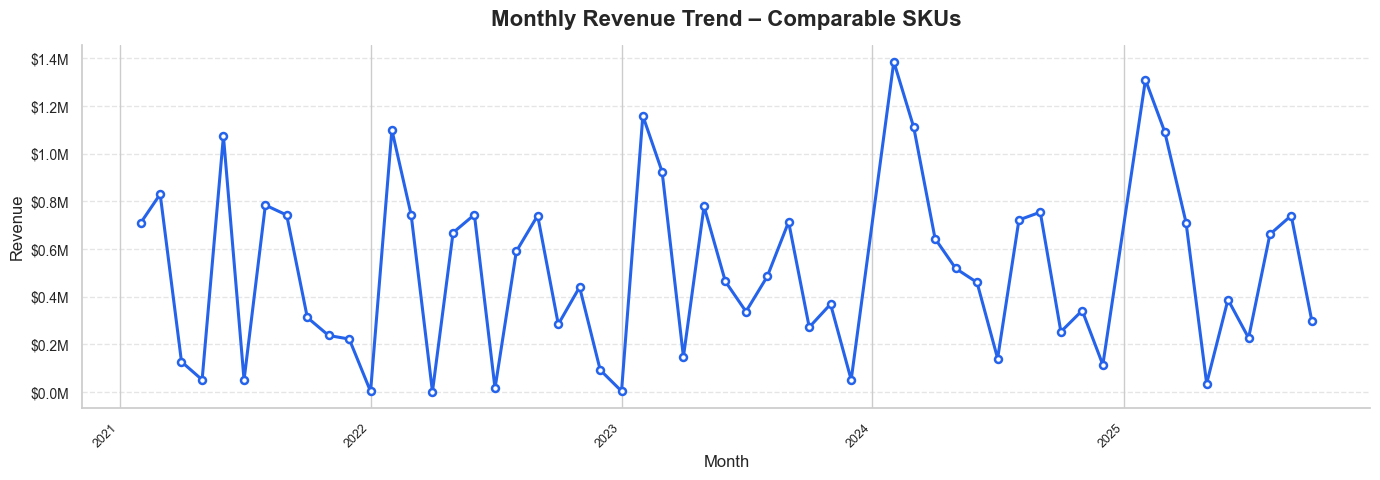

✓ Saved: charts/monthly_revenue_trend.png


In [25]:
# ------------------------------------------------------------
# Chart 1: Monthly Revenue Trend – Comparable SKUs
# ------------------------------------------------------------

# Aggregate: sum current_month_revenue by month, then sort chronologically
monthly_trend = (
    product_monthly_revenue
    .groupby("month", as_index=False)["current_month_revenue"]
    .sum()
    .sort_values("month")
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    monthly_trend["month"],
    monthly_trend["current_month_revenue"],
    color="#2563EB",      # professional blue
    linewidth=2.2,
    marker="o",           # circular markers at each data point
    markersize=5,
    markerfacecolor="white",
    markeredgewidth=1.8,
)

# ---- Formatting ----
ax.set_title("Monthly Revenue Trend – Comparable SKUs", fontsize=16, fontweight="bold", pad=14)
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Revenue", fontsize=12)

# Format Y-axis: show values in millions (e.g. "1.2M")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x/1_000_000:.1f}M")
)

# Rotate X-axis labels so month labels don't overlap
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=10)

ax.grid(axis="y", linestyle="--", alpha=0.5)
sns.despine()
plt.tight_layout()

# Save and display
fig.savefig(charts_dir / "monthly_revenue_trend.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Saved: charts/monthly_revenue_trend.png")

### Chart 2 – Revenue by City

**Business question:** Which cities generate the most revenue, and how large is the gap between them?

`revenue_by_city_store` contains one row per city–store-type combination. We group by `city` and sum `revenue` to get a single total per city before plotting. Cities are ordered from highest to lowest so the ranking is immediately visible.

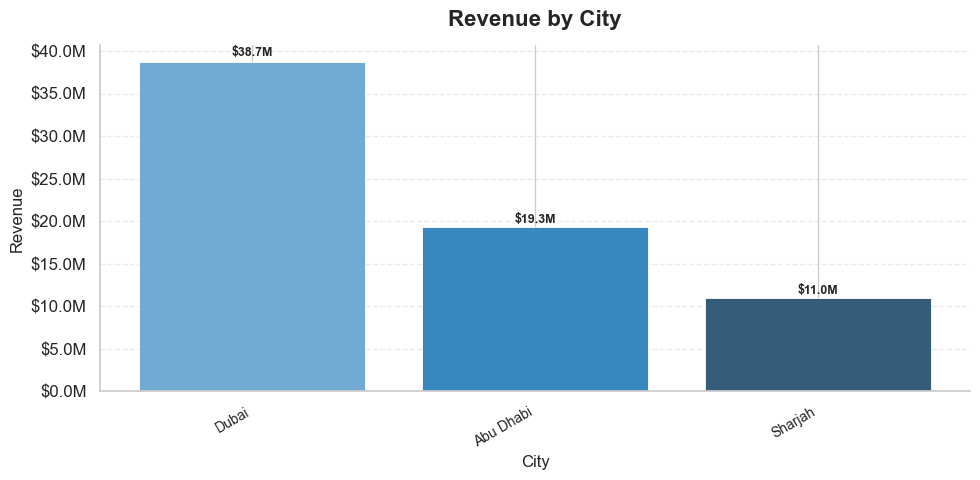

✓ Saved: charts/revenue_by_city.png


In [26]:
# ------------------------------------------------------------
# Chart 2: Revenue by City
# ------------------------------------------------------------

# Aggregate: sum revenue across all store types within each city
city_revenue = (
    revenue_by_city_store
    .groupby("city", as_index=False)["revenue"]
    .sum()
    .sort_values("revenue", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    city_revenue["city"],
    city_revenue["revenue"],
    color=sns.color_palette("Blues_d", len(city_revenue)),
    edgecolor="white",
    linewidth=0.6,
)

# ---- Value labels above each bar ----
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.01,
        f"${height/1_000_000:.1f}M",
        ha="center", va="bottom", fontsize=9, fontweight="bold"
    )

# ---- Formatting ----
ax.set_title("Revenue by City", fontsize=16, fontweight="bold", pad=14)
ax.set_xlabel("City", fontsize=12)
ax.set_ylabel("Revenue", fontsize=12)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x/1_000_000:.1f}M")
)
plt.xticks(rotation=30, ha="right", fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine()
plt.tight_layout()

fig.savefig(charts_dir / "revenue_by_city.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Saved: charts/revenue_by_city.png")

### Chart 3 – Top 10 Products by Revenue

**Business question:** Among the products captured in the Query 6 comparable-month output, which contribute the most revenue?

We group `product_monthly_revenue` by `sku_id` and `sku_name`, summing `current_month_revenue` across all available comparable-month records, then keep the top 10. Because Query 6 filters to SKU-months with a valid prior calendar month and a revenue decline, this ranking reflects the highest-revenue contributors within that subset — not necessarily the top products across all sales. A horizontal bar chart is used so product names stay fully readable.

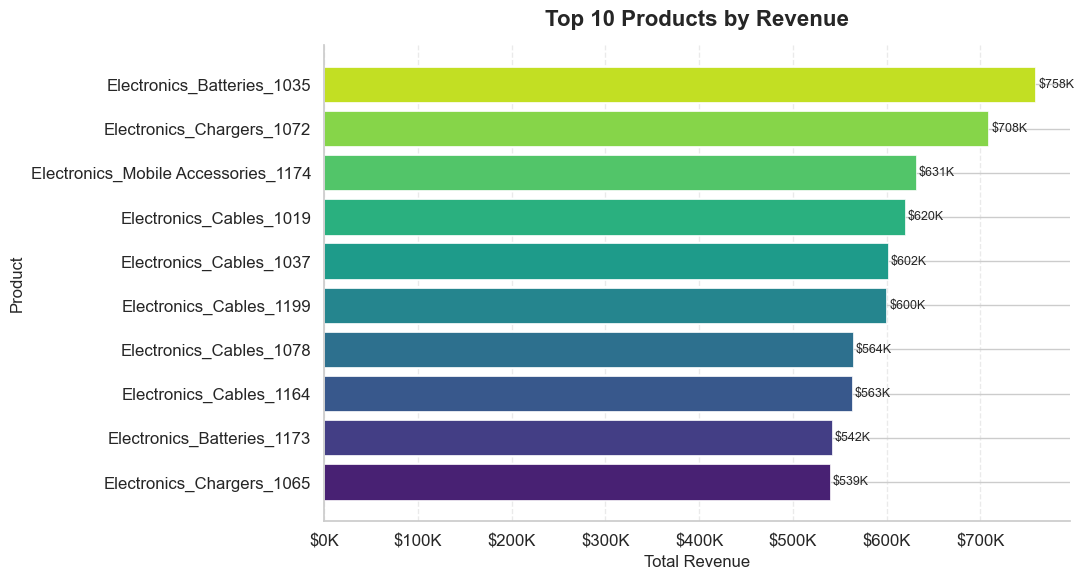

✓ Saved: charts/top_10_products.png


In [27]:
# ------------------------------------------------------------
# Chart 3: Top 10 Products by Revenue
# ------------------------------------------------------------

# Aggregate: total revenue per SKU across all months, keep top 10
top10_products = (
    product_monthly_revenue
    .groupby(["sku_id", "sku_name"], as_index=False)["current_month_revenue"]
    .sum()
    .nlargest(10, "current_month_revenue")
    .sort_values("current_month_revenue", ascending=True)  # ascending for horizontal bar
)

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    top10_products["sku_name"],
    top10_products["current_month_revenue"],
    color=sns.color_palette("viridis", 10),
    edgecolor="white",
    linewidth=0.5,
)

# ---- Value labels at end of each bar ----
for bar in bars:
    width = bar.get_width()
    ax.text(
        width * 1.005,
        bar.get_y() + bar.get_height() / 2,
        f"${width/1_000:.0f}K",
        va="center", ha="left", fontsize=9
    )

# ---- Formatting ----
ax.set_title("Top 10 Products by Revenue", fontsize=16, fontweight="bold", pad=14)
ax.set_xlabel("Total Revenue", fontsize=12)
ax.set_ylabel("Product", fontsize=12)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x/1_000:.0f}K")
)
ax.grid(axis="x", linestyle="--", alpha=0.4)
sns.despine()
plt.tight_layout()

fig.savefig(charts_dir / "top_10_products.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Saved: charts/top_10_products.png")

### Chart 4 – RFM Customer Segments

**Business question:** What proportion of our customer base falls into each value segment?

The RFM model classifies every customer as a Champion, Loyal, At Risk, or Lost customer. This pie chart shows the share of the customer base in each segment. Large "At Risk" or "Lost" slices indicate a retention challenge worth addressing immediately.

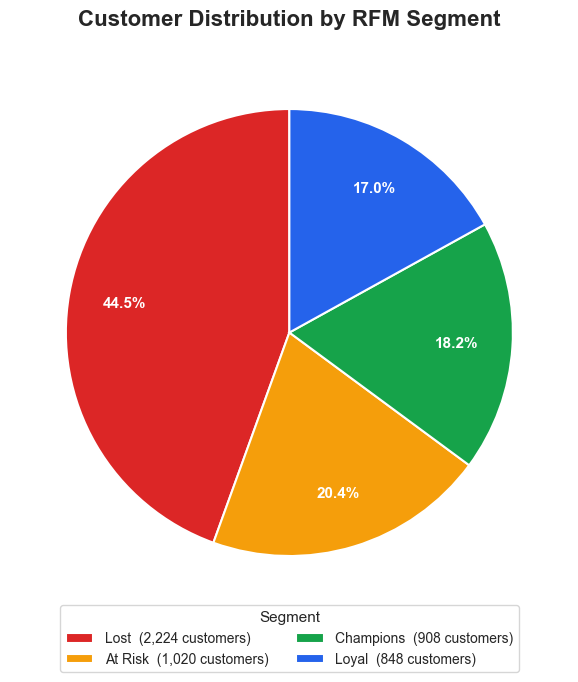

✓ Saved: charts/rfm_customer_segments.png


In [28]:
# ------------------------------------------------------------
# Chart 4: RFM Customer Segments – Pie Chart
# ------------------------------------------------------------

# Assign a distinct color to each segment
segment_colors = {
    "Champions": "#16A34A",   # green  – best customers
    "Loyal":     "#2563EB",   # blue   – reliable customers
    "At Risk":   "#F59E0B",   # amber  – need re-engagement
    "Lost":      "#DC2626",   # red    – churned customers
}

# Build ordered lists that align with the DataFrame rows
colors = [
    segment_colors.get(seg, "#6B7280")
    for seg in rfm_segments["customer_segment"]
]

fig, ax = plt.subplots(figsize=(8, 7))

wedges, texts, autotexts = ax.pie(
    rfm_segments["customer_count"],
    labels=None,                          # labels go in the legend
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    pctdistance=0.75,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)

# Make percentage text bold and readable
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")
    at.set_color("white")

# ---- Legend showing segment names and raw counts ----
legend_labels = [
    f"{row['customer_segment']}  ({row['customer_count']:,} customers)"
    for _, row in rfm_segments.iterrows()
]
ax.legend(
    wedges, legend_labels,
    title="Segment",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    fontsize=10,
    title_fontsize=11,
)

ax.set_title(
    "Customer Distribution by RFM Segment",
    fontsize=16, fontweight="bold", pad=20
)

plt.tight_layout()
fig.savefig(charts_dir / "rfm_customer_segments.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Saved: charts/rfm_customer_segments.png")

### Chart 5 – Cohort Retention Heatmap

**Business question:** How well does the business retain customers over time, and does retention vary by signup cohort?

Each row represents a group of customers who signed up in the same month (their "cohort"). Each column represents months since signup (`month_number` 0 = signup month). The cell colour shows the percentage of that cohort still making purchases in that month. Dark green = strong retention; dark red = heavy churn. Blank cells mean that combination has not yet occurred (recent cohorts haven't reached those months).

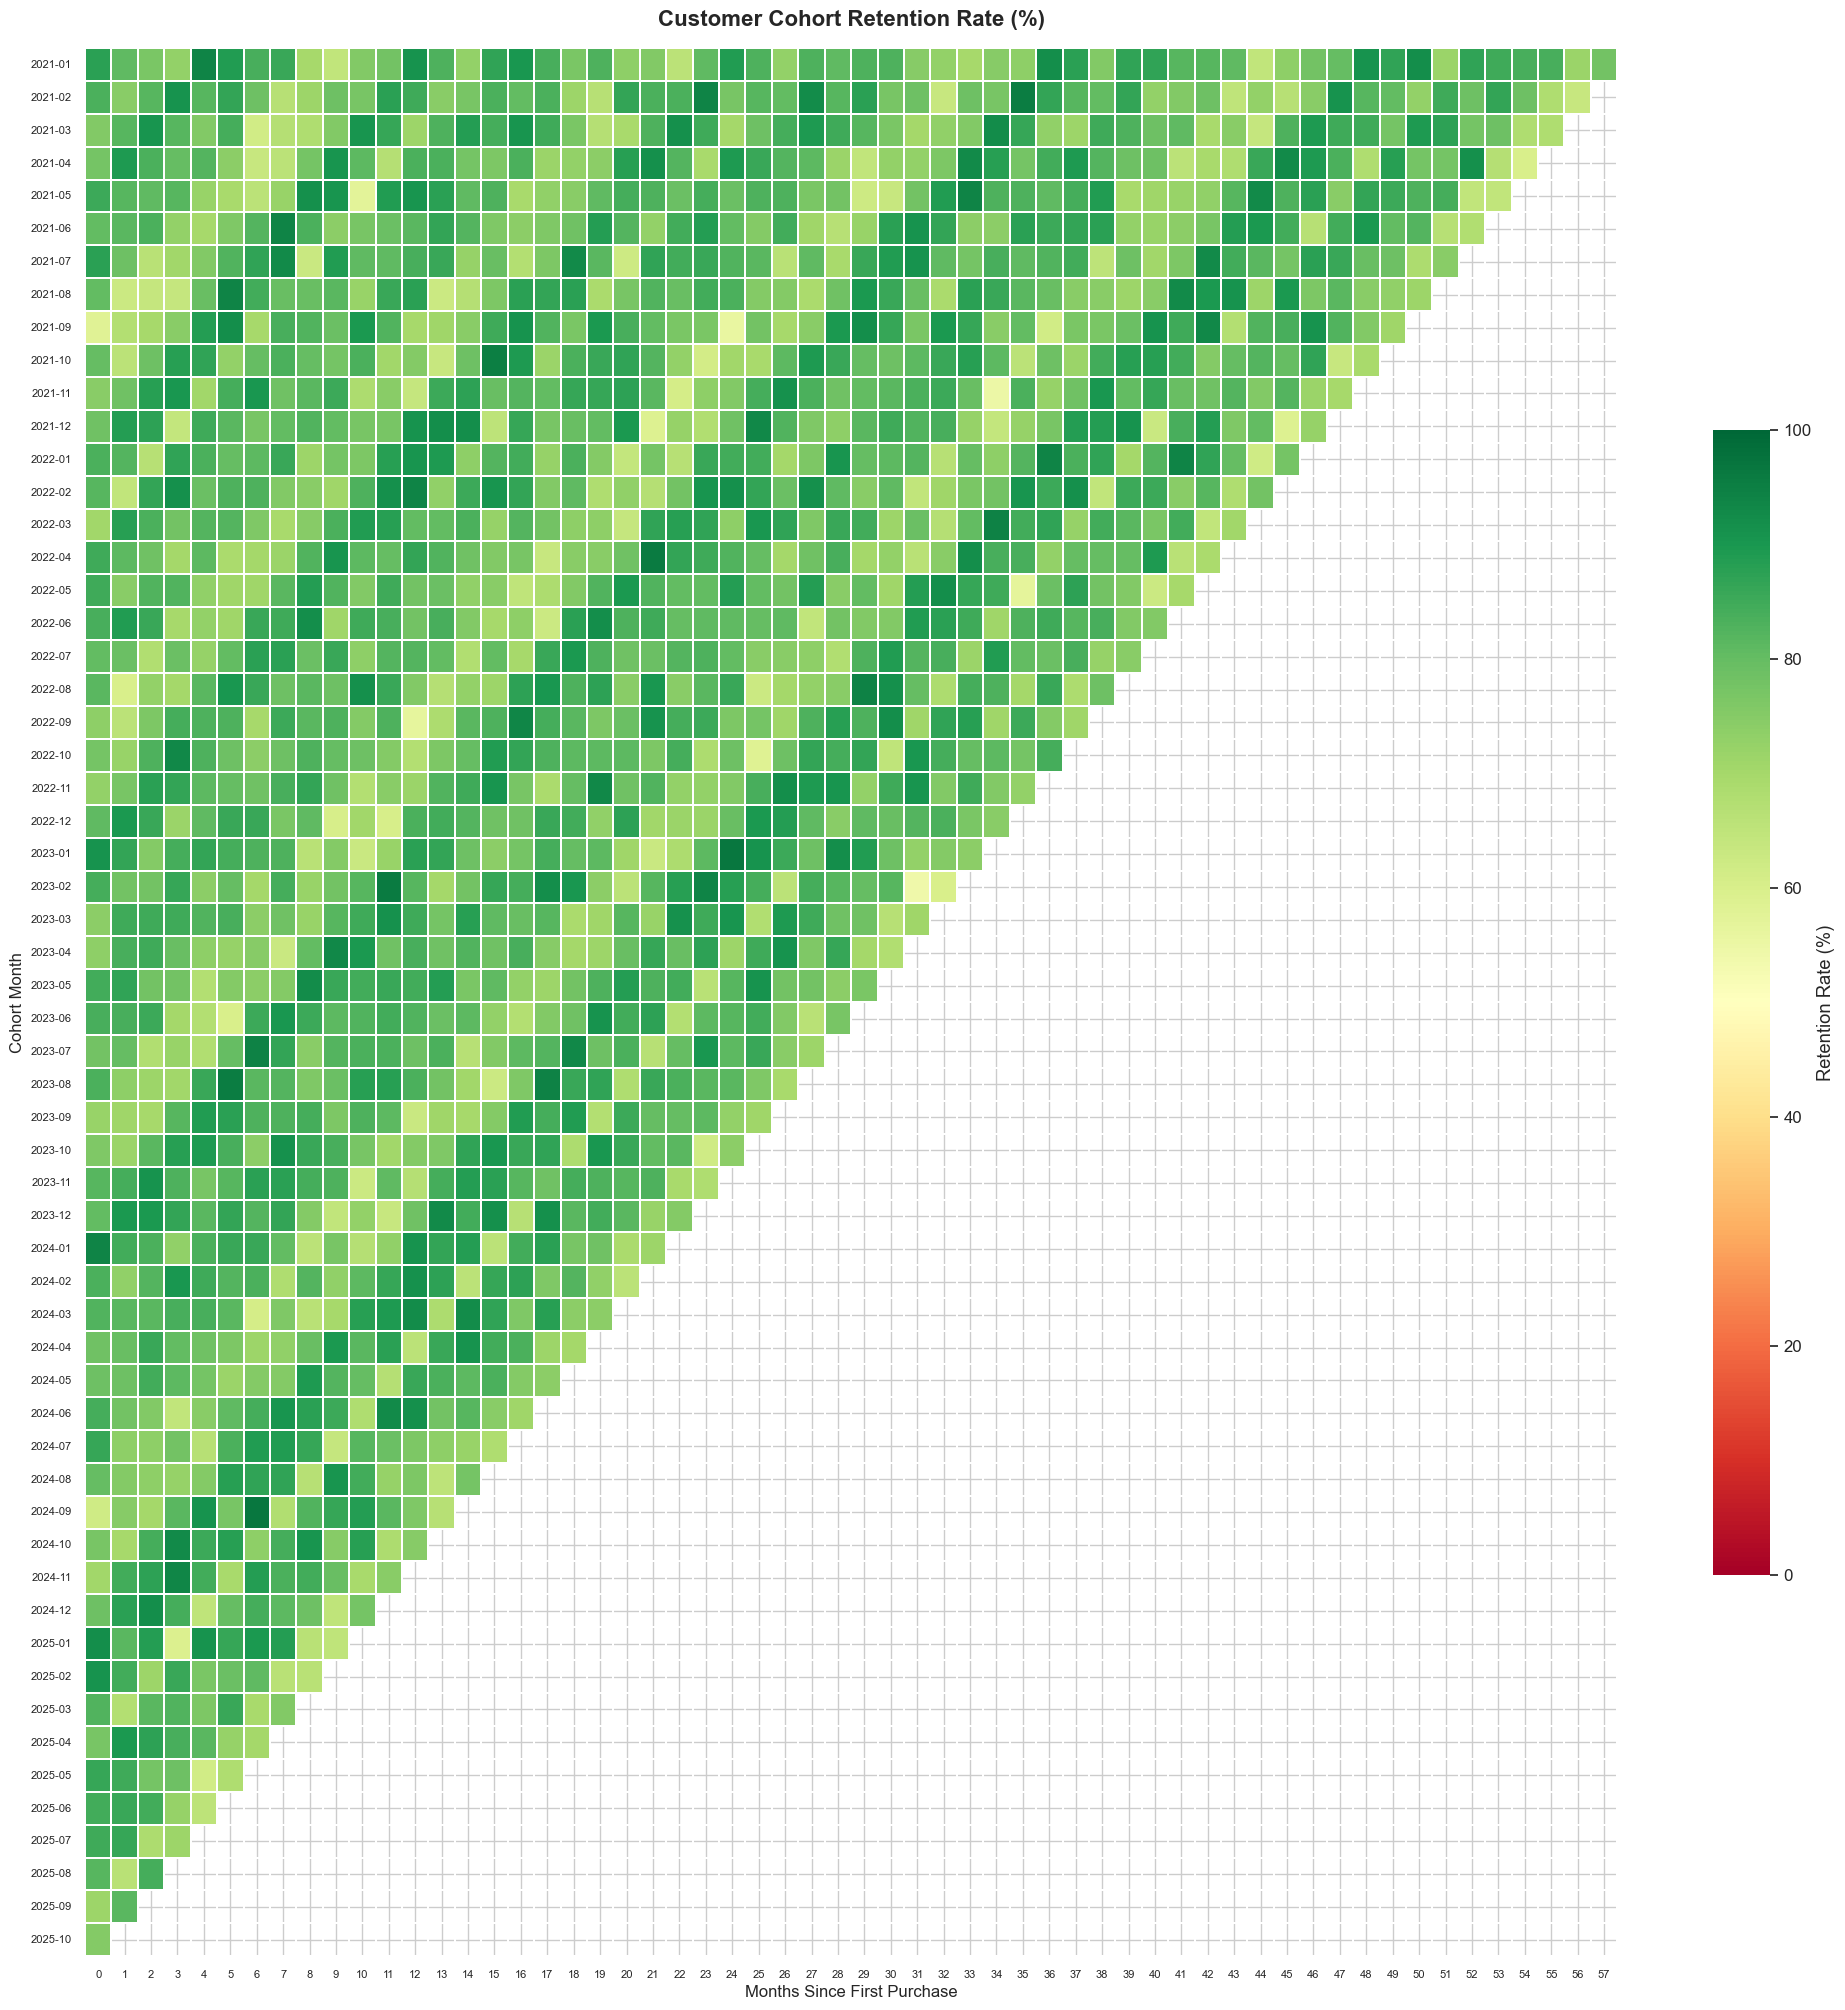

✓ Saved: charts/cohort_retention_heatmap.png


In [29]:
# ------------------------------------------------------------
# Chart 5: Cohort Retention Heatmap
# ------------------------------------------------------------

# Build pivot table: cohort months as rows, month_number as columns
#   - Sort rows chronologically using the datetime cohort_month column
#   - Missing combinations remain NaN → appear blank on the heatmap
retention_pivot = cohort_retention.pivot_table(
    index="cohort_month",
    columns="month_number",
    values="retention_rate",
    aggfunc="mean",           # in case of any duplicate rows
)
retention_pivot = retention_pivot.sort_index()   # chronological row order

# Format row labels as "YYYY-MM" strings for a cleaner Y-axis
retention_pivot.index = retention_pivot.index.strftime("%Y-%m")

# ---- Figure size: taller for many cohort rows, wider for many months ----
n_rows, n_cols = retention_pivot.shape
fig, ax = plt.subplots(figsize=(max(16, n_cols * 0.35), max(10, n_rows * 0.35)))

sns.heatmap(
    retention_pivot,
    ax=ax,
    cmap="RdYlGn",           # Red (low) → Yellow → Green (high)
    vmin=0,
    vmax=100,
    linewidths=0.3,
    linecolor="white",
    annot=False,              # annotations would be unreadable at this size
    mask=retention_pivot.isnull(),   # blank out missing cohort-month cells
    cbar_kws={"label": "Retention Rate (%)", "shrink": 0.6},
)

# ---- Formatting ----
ax.set_title(
    "Customer Cohort Retention Rate (%)",
    fontsize=16, fontweight="bold", pad=16
)
ax.set_xlabel("Months Since First Purchase", fontsize=12)
ax.set_ylabel("Cohort Month", fontsize=12)
ax.tick_params(axis="x", labelsize=8, rotation=0)
ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
fig.savefig(charts_dir / "cohort_retention_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Saved: charts/cohort_retention_heatmap.png")

## 6. Export Summary Metrics for Power BI

This section builds a single **long-format** table called `summary_metrics` that consolidates every key business number from the notebook into one structured file. Long format means each metric occupies its own row — this is the layout Power BI, Tableau, and Excel PivotTables consume most easily.

**Columns:**

| Column | Purpose |
|---|---|
| `metric_category` | Broad group (e.g. "Overall Performance", "Geography") |
| `metric_name` | What is being measured (e.g. "City Revenue") |
| `dimension_value` | The entity the metric applies to (e.g. "Dubai", "Electronics") |
| `metric_value` | The numeric result — always a number, never text |
| `unit` | Currency, Percentage, or Count |

All values are calculated dynamically from the loaded DataFrames — no numbers are hard-coded.

In [30]:
# ============================================================
# Section 6: Build summary_metrics — Power BI long-format table
# ============================================================
# Each metric is appended as one or more rows to this list.
# At the end we convert the list to a DataFrame and export it.
rows = []

# Helper: add a single metric row
def add(category, name, dimension, value, unit):
    rows.append({
        "metric_category": category,
        "metric_name":     name,
        "dimension_value": dimension,
        "metric_value":    round(float(value), 2),
        "unit":            unit,
    })


# ── 1. Overall Performance ────────────────────────────────────────────────────
# Total revenue: sum city-level revenue from Query 1 (revenue_by_city_store).
# Query 1 joins sales → stores with no filters and no LIMIT, making it the
# broadest and most complete revenue figure available in the Day 2 outputs.
total_revenue = city_revenue["revenue"].sum()
add("Overall Performance", "Total Revenue", "All", total_revenue, "Currency")

# The following three metrics use monthly_trend, built from Query 6.
# Query 6 filters to SKU-months with a valid prior calendar month AND a revenue
# decline — so these figures reflect the comparable-SKU subset only, not
# all-company monthly revenue. They are useful for directional trend analysis.
avg_monthly_rev = monthly_trend["current_month_revenue"].mean()
add("Overall Performance", "Average Comparable-SKU Monthly Revenue", "All", avg_monthly_rev, "Currency")

# Highest revenue month within the comparable-SKU output
max_row = monthly_trend.loc[monthly_trend["current_month_revenue"].idxmax()]
add(
    "Overall Performance",
    "Highest Comparable-SKU Monthly Revenue",
    str(max_row["month"])[:7],     # "YYYY-MM" label for Power BI
    max_row["current_month_revenue"],
    "Currency",
)

# Lowest revenue month within the comparable-SKU output
min_row = monthly_trend.loc[monthly_trend["current_month_revenue"].idxmin()]
add(
    "Overall Performance",
    "Lowest Comparable-SKU Monthly Revenue",
    str(min_row["month"])[:7],
    min_row["current_month_revenue"],
    "Currency",
)


# ── 2. Geography ──────────────────────────────────────────────────────────────
# city_revenue was built in Chart 2 — one row per city
city_total = city_revenue["revenue"].sum()

for _, cr in city_revenue.iterrows():
    # Absolute revenue per city
    add("Geography", "City Revenue", cr["city"], cr["revenue"], "Currency")
    # Revenue share as a percentage of all city revenue
    share = cr["revenue"] / city_total * 100
    add("Geography", "City Revenue Share", cr["city"], share, "Percentage")


# ── 3. Product Performance ────────────────────────────────────────────────────
# Category revenue from revenue_by_category (Query 2).
# NOTE: Query 2 applies LIMIT 5 — only the top 5 categories by revenue are
# returned. These rows must NOT be summed to represent overall gross revenue;
# they are a ranked leaderboard, not a complete category breakdown.
for _, rc in revenue_by_category.iterrows():
    add("Product Performance", "Top Category Revenue", rc["category"], rc["revenue"], "Currency")

# Top 10 product revenue from top10_products (built from Query 6 in Chart 3).
# Rankings are based on comparable-month records only (SKUs with a valid prior
# month and a revenue decline) — not all-time product revenue across all sales.
for _, tp in top10_products.iterrows():
    add(
        "Product Performance",
        "Top Comparable-SKU Product Revenue",
        tp["sku_name"],
        tp["current_month_revenue"],
        "Currency",
    )


# ── 4. Customer Performance ───────────────────────────────────────────────────
# repeat_purchase_metrics has exactly one data row (query 9)
rp = repeat_purchase_metrics.iloc[0]
add("Customer Performance", "Total Customers",        "All", rp["total_customers"],           "Count")
add("Customer Performance", "Repeat Customers",       "All", rp["repeat_customers"],          "Count")
add("Customer Performance", "Repeat Purchase Rate",   "All", rp["repeat_purchase_rate_pct"],  "Percentage")


# ── 5. RFM Segments ───────────────────────────────────────────────────────────
rfm_total_customers = rfm_segments["customer_count"].sum()

for _, seg in rfm_segments.iterrows():
    add("RFM Segments", "Segment Customer Count", seg["customer_segment"], seg["customer_count"], "Count")
    share = seg["customer_count"] / rfm_total_customers * 100
    add("RFM Segments", "Segment Customer Share", seg["customer_segment"], share, "Percentage")


# ── 6. Promotion Performance ──────────────────────────────────────────────────
# promotion_performance has one row per period_type (During / Outside Promotion)
for _, pp in promotion_performance.iterrows():
    add("Promotion Performance", "Period Total Revenue",          pp["period_type"], pp["total_revenue"],              "Currency")
    add("Promotion Performance", "Avg Revenue per Transaction",   pp["period_type"], pp["avg_revenue_per_transaction"], "Currency")


# ── 7. Retention ─────────────────────────────────────────────────────────────
# Average retention rate for key milestone months (1, 3, 6, 12)
# Only include a milestone if that month_number exists in the data
available_months = cohort_retention["month_number"].unique()
milestone_months = [1, 3, 6, 12]

for m in milestone_months:
    if m in available_months:
        avg_rate = cohort_retention.loc[
            cohort_retention["month_number"] == m, "retention_rate"
        ].mean()
        add("Retention", "Avg Retention Rate", f"Month {m}", avg_rate, "Percentage")


# ── Assemble and export ───────────────────────────────────────────────────────
summary_metrics = pd.DataFrame(rows)

# Export to CSV at the Project-1 root — index=False keeps the file clean
output_path = BASE_DIR / "summary_metrics.csv"
summary_metrics.to_csv(output_path, index=False)

# ── Display and confirm ───────────────────────────────────────────────────────
print(f"Total metrics exported: {len(summary_metrics)}")
print("✓ Saved: summary_metrics.csv")
print()
display(summary_metrics)

Total metrics exported: 44
✓ Saved: summary_metrics.csv



,metric_category,metric_name,dimension_value,metric_value,unit
0,Overall Performance,Total Revenue,All,"69,102,366.14",Currency
1,Overall Performance,Average Comparable-SKU Monthly Revenue,All,"512,808.57",Currency
2,Overall Performance,Highest Comparable-SKU Monthly Revenue,2024-02,"1,386,609.95",Currency
3,Overall Performance,Lowest Comparable-SKU Monthly Revenue,2022-04,"1,941.35",Currency
4,Geography,City Revenue,Dubai,"38,740,730.80",Currency
5,Geography,City Revenue Share,Dubai,56.06,Percentage
6,Geography,City Revenue,Abu Dhabi,"19,343,932.08",Currency
7,Geography,City Revenue Share,Abu Dhabi,27.99,Percentage
8,Geography,City Revenue,Sharjah,"11,017,703.26",Currency
9,Geography,City Revenue Share,Sharjah,15.94,Percentage


## 7. One-Page Executive Summary PDF

This section generates `executive_summary.pdf` — a single landscape Letter page — using ReportLab's canvas API. All numbers are pulled dynamically from the DataFrames already in memory; nothing is hard-coded.

The page is divided into:
- **Header** with title, subtitle, and data-source note
- **Four KPI cards** across the top
- **Three business-question panels** with findings and recommendations
- **Recommended Actions** block
- **Footer** with data lineage

In [ ]:
# ============================================================
# Section 7: One-Page Executive Summary PDF
# ============================================================
import os
import textwrap
from reportlab.pdfgen import canvas
from reportlab.lib.pagesizes import landscape, letter
from reportlab.lib.utils import ImageReader

# ── Page geometry ─────────────────────────────────────────────────────────────
PAGE_W, PAGE_H = landscape(letter)   # 792 x 612 pts
MARGIN         = 28
INNER_W        = PAGE_W - 2 * MARGIN

# ── Colour palette ────────────────────────────────────────────────────────────
NAVY      = (0.07, 0.13, 0.31)    # header / card backgrounds
TEAL      = (0.07, 0.53, 0.55)    # accent / section rule
LT_GRAY   = (0.94, 0.95, 0.96)    # card fill / zebra rows
WHITE     = (1.00, 1.00, 1.00)
DARK_TEXT = (0.12, 0.12, 0.16)
MID_TEXT  = (0.35, 0.38, 0.44)

# ── Formatting helpers ────────────────────────────────────────────────────────
def fmt_currency(val):
    """Format a number as $X.XM or $X,XXX."""
    v = float(val)
    if v >= 1_000_000:
        return f"${v/1_000_000:.2f}M"
    if v >= 1_000:
        return f"${v:,.0f}"
    return f"${v:.2f}"

def fmt_pct(val):
    """Format a number as XX.X%."""
    return f"{float(val):.1f}%"

def draw_wrapped_text(c, text, x, y, width, font, size, color, leading=None):
    """
    Draw text wrapped to `width` pts. Returns the y position after the last line.
    Uses ASCII characters only — no Unicode dashes or smart quotes.
    """
    if leading is None:
        leading = size + 2
    c.setFont(font, size)
    c.setFillColorRGB(*color)
    # Estimate characters per line from point width (approx 0.55 pt/char)
    char_width = size * 0.55
    chars_per_line = max(10, int(width / char_width))
    lines = []
    for paragraph in text.split("\n"):
        if paragraph.strip() == "":
            lines.append("")
        else:
            lines.extend(textwrap.wrap(paragraph, chars_per_line) or [""])
    for line in lines:
        c.drawString(x, y, line)
        y -= leading
    return y

# ── Pre-calculate all dynamic values ─────────────────────────────────────────
gross_revenue      = city_revenue["revenue"].sum()
top_city_row       = city_revenue.iloc[0]          # already sorted descending
top_city_name      = top_city_row["city"]
top_city_revenue   = top_city_row["revenue"]
top_city_share     = top_city_revenue / gross_revenue * 100

rp_row             = repeat_purchase_metrics.iloc[0]
repeat_rate        = float(rp_row["repeat_purchase_rate_pct"])
total_customers    = int(rp_row["total_customers"])
repeat_customers   = int(rp_row["repeat_customers"])

# Largest RFM segment by customer count
rfm_sorted         = rfm_segments.sort_values("customer_count", ascending=False)
top_seg_row        = rfm_sorted.iloc[0]
top_seg_name       = top_seg_row["customer_segment"]
top_seg_count      = int(top_seg_row["customer_count"])
top_seg_share      = top_seg_count / int(rfm_segments["customer_count"].sum()) * 100

# Lost + At Risk combined
risk_segs          = rfm_segments[rfm_segments["customer_segment"].isin(["Lost", "At Risk"])]
risk_count         = int(risk_segs["customer_count"].sum())
risk_share         = risk_count / int(rfm_segments["customer_count"].sum()) * 100

# Champions + Loyal combined
loyal_segs         = rfm_segments[rfm_segments["customer_segment"].isin(["Champions", "Loyal"])]
loyal_count        = int(loyal_segs["customer_count"].sum())

# Segment breakdown string
seg_parts = []
for _, row in rfm_sorted.iterrows():
    seg_parts.append(
        f"{row['customer_segment']}: {int(row['customer_count']):,} "
        f"({row['customer_count']/rfm_segments['customer_count'].sum()*100:.1f}%)"
    )
seg_breakdown = " | ".join(seg_parts)

# Top category (Query 2 is LIMIT 5 ranked output - not gross total)
top_cat_row        = revenue_by_category.sort_values("revenue", ascending=False).iloc[0]
top_cat_name       = top_cat_row["category"]
top_cat_revenue    = top_cat_row["revenue"]

# Promotion vs outside average revenue per transaction
promo_df           = promotion_performance.copy()
during_row         = promo_df[promo_df["period_type"] == "During Promotion"]
outside_row        = promo_df[promo_df["period_type"] == "Outside Promotion"]
during_avg  = float(during_row["avg_revenue_per_transaction"].values[0]) if len(during_row) else 0
outside_avg = float(outside_row["avg_revenue_per_transaction"].values[0]) if len(outside_row) else 0

# Cohort retention at milestone months (only if data exists)
retention_notes = []
for m_num, label in [(1, "Month 1"), (3, "Month 3"), (6, "Month 6"), (12, "Month 12")]:
    subset = cohort_retention[cohort_retention["month_number"] == m_num]
    if len(subset) > 0:
        avg_r = subset["retention_rate"].mean()
        retention_notes.append(f"{label}: {avg_r:.1f}%")
retention_str = " | ".join(retention_notes) if retention_notes else "Insufficient data"

# ── Build PDF ─────────────────────────────────────────────────────────────────
pdf_path = BASE_DIR / "executive_summary.pdf"
c = canvas.Canvas(str(pdf_path), pagesize=landscape(letter))

# ── A. Header bar ─────────────────────────────────────────────────────────────
HEADER_H = 56
c.setFillColorRGB(*NAVY)
c.rect(0, PAGE_H - HEADER_H, PAGE_W, HEADER_H, fill=1, stroke=0)

c.setFillColorRGB(*WHITE)
c.setFont("Helvetica-Bold", 17)
c.drawString(MARGIN, PAGE_H - 22, "Retail Intelligence - Executive Summary")

c.setFont("Helvetica", 10)
c.drawString(MARGIN, PAGE_H - 37, "Day 4 Python EDA and Business Insights")

c.setFont("Helvetica-Oblique", 8)
c.drawString(MARGIN, PAGE_H - 50,
    "Analysis based on Day 2 KPI exports and Day 3 advanced analytics exports.")

# right-aligned date
c.setFont("Helvetica", 8)
date_str = "August 2026"
c.drawRightString(PAGE_W - MARGIN, PAGE_H - 37, date_str)

# ── B. Four KPI cards ─────────────────────────────────────────────────────────
KPI_Y_TOP   = PAGE_H - HEADER_H - 8
KPI_H       = 52
KPI_PAD     = 6
card_count  = 4
card_w      = (INNER_W - (card_count - 1) * KPI_PAD) / card_count
card_x_list = [MARGIN + i * (card_w + KPI_PAD) for i in range(card_count)]

kpi_data = [
    ("Overall Gross Revenue",    fmt_currency(gross_revenue),          "Query 1 (stores join, no filter)"),
    ("Leading City",             f"{top_city_name}",                   f"Revenue share: {fmt_pct(top_city_share)}"),
    ("Repeat Purchase Rate",     fmt_pct(repeat_rate),                 f"{repeat_customers:,} of {total_customers:,} customers"),
    ("Largest RFM Segment",      top_seg_name,                         f"{top_seg_count:,} customers ({fmt_pct(top_seg_share)})"),
]

for i, (label, value, sub) in enumerate(kpi_data):
    cx = card_x_list[i]
    # Card background
    c.setFillColorRGB(*LT_GRAY)
    c.roundRect(cx, KPI_Y_TOP - KPI_H, card_w, KPI_H, 4, fill=1, stroke=0)
    # Teal top accent strip
    c.setFillColorRGB(*TEAL)
    c.roundRect(cx, KPI_Y_TOP - 5, card_w, 5, 2, fill=1, stroke=0)
    # Label
    c.setFillColorRGB(*MID_TEXT)
    c.setFont("Helvetica", 7.5)
    c.drawString(cx + 6, KPI_Y_TOP - 18, label)
    # Value
    c.setFillColorRGB(*NAVY)
    c.setFont("Helvetica-Bold", 13)
    c.drawString(cx + 6, KPI_Y_TOP - 32, value)
    # Sub-label
    c.setFillColorRGB(*MID_TEXT)
    c.setFont("Helvetica", 7)
    c.drawString(cx + 6, KPI_Y_TOP - 44, sub)

# ── Layout constants for the three body panels ────────────────────────────────
BODY_TOP   = KPI_Y_TOP - KPI_H - 10
FOOTER_H   = 22
BODY_BOT   = FOOTER_H + 4
BODY_H     = BODY_TOP - BODY_BOT

# Three columns: Q1, Q2, Q3 — with two chart slots on the right of Q1 and Q3
COL_GAP    = 8
# Columns: Q1 wider (no chart), Q2 medium, Q3 wider (no chart)
# We'll split into: left panel, center panel, right panel + chart strip
PANEL_W    = (INNER_W - 2 * COL_GAP) / 3

left_x   = MARGIN
center_x = MARGIN + PANEL_W + COL_GAP
right_x  = MARGIN + 2 * (PANEL_W + COL_GAP)

# Narrower text panels + chart strip layout:
# Left panel gets a chart on its right edge; right panel similarly
CHART_W    = 118
CHART_H    = 90
TEXT_W_LR  = PANEL_W - CHART_W - 4    # text width when chart is present
TEXT_W_CTR = PANEL_W                  # center panel uses full width

def draw_panel_header(c, x, y, w, title):
    """Draw a teal section title rule + label."""
    c.setFillColorRGB(*TEAL)
    c.rect(x, y - 1, w, 2, fill=1, stroke=0)
    c.setFillColorRGB(*TEAL)
    c.setFont("Helvetica-Bold", 8.5)
    c.drawString(x, y + 3, title)
    return y - 12   # return y below the header

# ── C. Business question panels ───────────────────────────────────────────────

# -- Panel 1: Revenue concentration ─
py = draw_panel_header(c, left_x, BODY_TOP, PANEL_W,
                       "BQ1: Where is revenue concentrated?")

q1_lines = (
    f"Gross Revenue (Query 1): {fmt_currency(gross_revenue)}\n"
    f"Leading city: {top_city_name} ({fmt_pct(top_city_share)} of gross revenue)\n"
    f"Top category (Query 2 - ranked top-5 output, NOT gross total):\n"
    f"  {top_cat_name}: {fmt_currency(top_cat_revenue)}\n"
    f"Avg revenue/transaction:\n"
    f"  During promotion: {fmt_currency(during_avg)}\n"
    f"  Outside promotion: {fmt_currency(outside_avg)}\n"
    f"Interpretation: Revenue is geographically concentrated.\n"
    f"Promotions show a measurable difference in avg transaction\n"
    f"value versus non-promotion periods."
)
py = draw_wrapped_text(c, q1_lines, left_x, py, TEXT_W_LR,
                       "Helvetica", 7.2, DARK_TEXT, leading=10)

# Chart: revenue_by_city
chart1_path = str(charts_dir / "revenue_by_city.png")
if os.path.exists(chart1_path):
    chart1_x = left_x + TEXT_W_LR + 4
    chart1_y = BODY_TOP - CHART_H - 10
    c.drawImage(
        ImageReader(chart1_path),
        chart1_x, chart1_y,
        width=CHART_W, height=CHART_H,
        preserveAspectRatio=True, anchor="nw"
    )

# -- Panel 2: Customer portfolio ─
py2 = draw_panel_header(c, center_x, BODY_TOP, PANEL_W,
                        "BQ2: What does the customer portfolio reveal?")

q2_lines = (
    f"Total customers: {total_customers:,}\n"
    f"Repeat purchase rate: {fmt_pct(repeat_rate)}\n"
    f"RFM segments:\n"
    f"  {seg_breakdown}\n"
    f"Risk: Lost + At Risk = {risk_count:,} customers "
    f"({fmt_pct(risk_share)}) require\n"
    f"  re-engagement to prevent permanent revenue loss.\n"
    f"Champions + Loyal = {loyal_count:,} customers drive\n"
    f"  disproportionate revenue and need retention rewards.\n"
    f"Recommendation: Launch targeted win-back campaigns\n"
    f"for Lost/At Risk. Reward Champions and Loyal customers\n"
    f"with exclusive offers to maintain engagement."
)
py2 = draw_wrapped_text(c, q2_lines, center_x, py2, TEXT_W_CTR,
                        "Helvetica", 7.2, DARK_TEXT, leading=10)

# -- Panel 3: Cohort retention ─
py3 = draw_panel_header(c, right_x, BODY_TOP, PANEL_W,
                        "BQ3: What does cohort retention indicate?")

q3_lines = (
    f"Avg retention by month post-acquisition:\n"
    f"  {retention_str}\n"
    f"Interpretation: Retention rates indicate whether the\n"
    f"customer base is stable, improving, or weakening over\n"
    f"successive months after signup. Month-0 rates near 100%\n"
    f"are expected; sustained rates above 70% at Month 6+\n"
    f"indicate strong loyalty.\n"
    f"Recommendation: Monitor cohort decay curves monthly\n"
    f"in Power BI. Trigger re-engagement at months where\n"
    f"retention shows consistent dips.\n"
    f"Note: Monthly trend and top-product analysis use\n"
    f"comparable SKU-month records from Query 6 (declining\n"
    f"months only) - directional, not gross-revenue total."
)
py3 = draw_wrapped_text(c, q3_lines, right_x, py3, TEXT_W_LR,
                        "Helvetica", 7.2, DARK_TEXT, leading=10)

# Chart: RFM pie
chart2_path = str(charts_dir / "rfm_customer_segments.png")
if os.path.exists(chart2_path):
    chart2_x = right_x + TEXT_W_LR + 4
    chart2_y = BODY_TOP - CHART_H - 10
    c.drawImage(
        ImageReader(chart2_path),
        chart2_x, chart2_y,
        width=CHART_W, height=CHART_H,
        preserveAspectRatio=True, anchor="nw"
    )

# ── D. Recommended Actions ────────────────────────────────────────────────────
# Positioned below the three panels, before the footer
actions_y = BODY_BOT + FOOTER_H + 2
c.setFillColorRGB(*NAVY)
c.rect(MARGIN, actions_y, INNER_W, 36, fill=1, stroke=0)

c.setFillColorRGB(*WHITE)
c.setFont("Helvetica-Bold", 8)
c.drawString(MARGIN + 6, actions_y + 26, "Recommended Actions")
c.setFont("Helvetica", 7.5)
actions = [
    "1. Protect and expand revenue in the leading city while developing lower-revenue cities.",
    "2. Launch win-back activity for Lost and At Risk customers; reward Champions and Loyal customers.",
    "3. Track cohort retention and promotion performance monthly in Power BI.",
]
action_col_w = INNER_W / len(actions)
for i, action in enumerate(actions):
    ax_pos = MARGIN + 6 + i * action_col_w
    # Wrap each action to fit its column
    wrapped = textwrap.wrap(action, int(action_col_w / 4.2)) or [action]
    ay = actions_y + 17
    for line in wrapped:
        c.drawString(ax_pos, ay, line)
        ay -= 9

# ── E. Footer ─────────────────────────────────────────────────────────────────
c.setFillColorRGB(*LT_GRAY)
c.rect(0, 0, PAGE_W, FOOTER_H, fill=1, stroke=0)

c.setFillColorRGB(*MID_TEXT)
c.setFont("Helvetica", 7)
c.drawString(MARGIN, 8,
    "Source: Retail Intelligence Project - Day 2 and Day 3 CSV exports")
c.drawRightString(PAGE_W - MARGIN, 8,
    "Prepared with Python, pandas, matplotlib, seaborn, and ReportLab")

# ── Finalise ──────────────────────────────────────────────────────────────────
c.showPage()
c.save()

# Verify the file was written and is non-empty
pdf_size = os.path.getsize(str(pdf_path))
assert pdf_size > 0, "PDF was created but appears to be empty!"

print(f"Total metrics in summary_metrics: {len(summary_metrics)}")
print(f"✓ Saved: executive_summary.pdf")
print(f"  File size: {pdf_size / 1024:.1f} KB")